# Iris Flower Classification
**CodeAlpha Data Science Internship - Task 1**

Goal: classify Iris flowers (setosa, versicolor, virginica) from their measurements.

Place `Iris.csv` in the same folder as this notebook.

In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
file = (glob.glob("*ris*.csv") + glob.glob("**/*ris*.csv", recursive=True))[0]
df = pd.read_csv(file)
print("Loaded:", file)
df.head()

Loaded: Iris.csv


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 1. Data overview

In [2]:
print(df.shape)
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
df.describe()

(150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Missing values:
 Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Duplicate rows: 0


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [3]:
# Detect target column and drop the id column
target = [c for c in df.columns if c.lower() == "species"][0]
df = df.drop(columns=[c for c in df.columns if c.lower() == "id"])
features = [c for c in df.columns if c != target]
print("Target:", target)
print("Features:", features)
df[target].value_counts()

Target: Species
Features: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## 2. Exploratory analysis

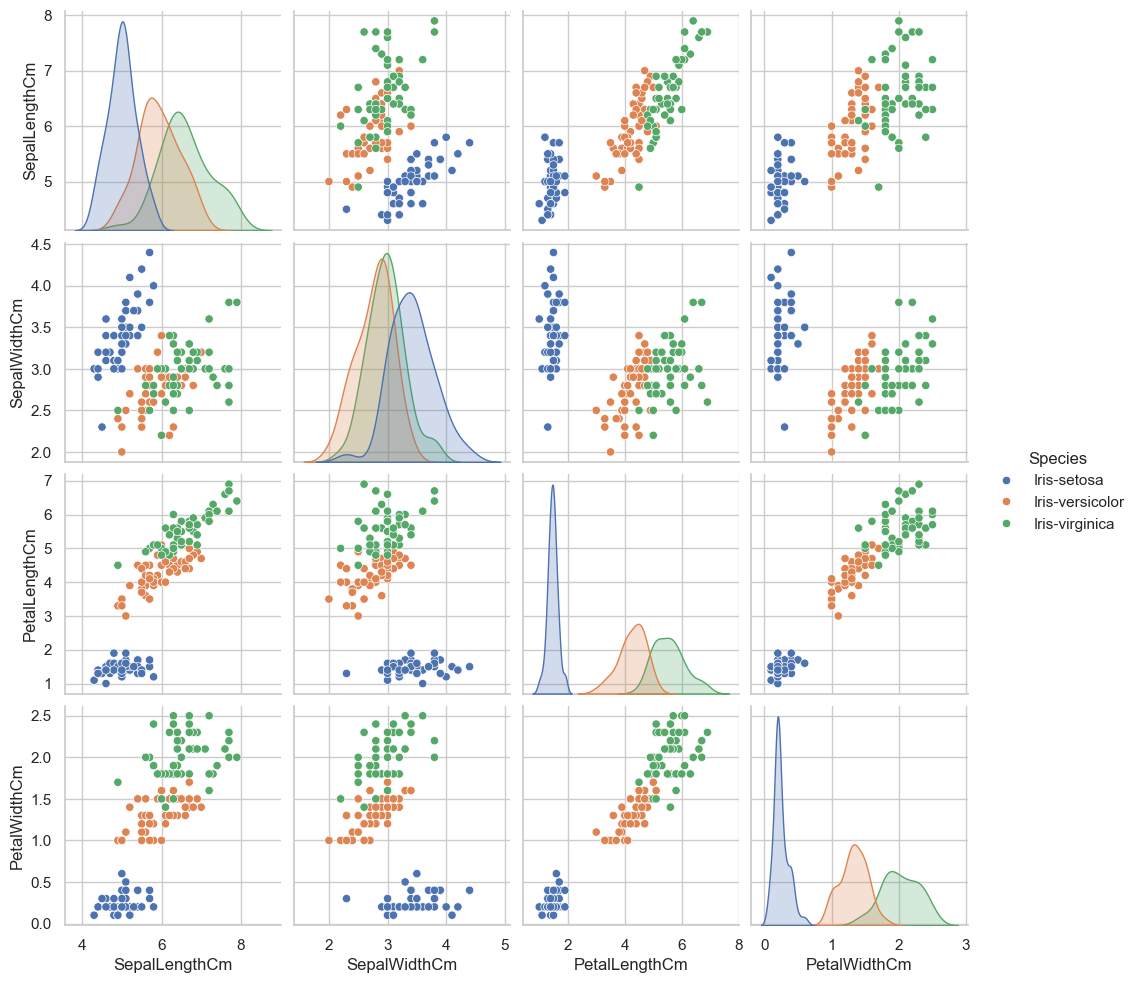

In [4]:
sns.pairplot(df, hue=target, corner=False)
plt.show()

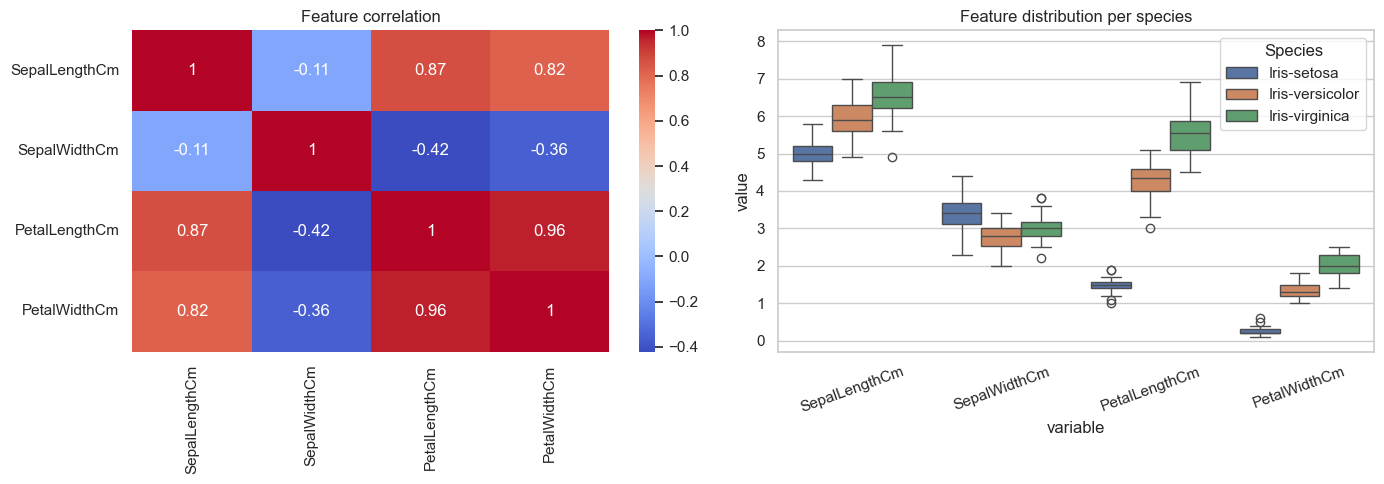

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", ax=axes[0])
axes[0].set_title("Feature correlation")
df.melt(id_vars=target, value_vars=features).pipe(
    lambda d: sns.boxplot(data=d, x="variable", y="value", hue=target, ax=axes[1]))
axes[1].set_title("Feature distribution per species")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 3. Train / test split

In [6]:
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (120, 4) Test: (30, 4)


## 4. Compare models (5-fold cross-validation on training data)

Logistic Regression  CV accuracy: 0.9583 (+/- 0.0264)
KNN                  CV accuracy: 0.9667 (+/- 0.0312)
SVM                  CV accuracy: 0.9667 (+/- 0.0312)
Random Forest        CV accuracy: 0.9500 (+/- 0.0167)


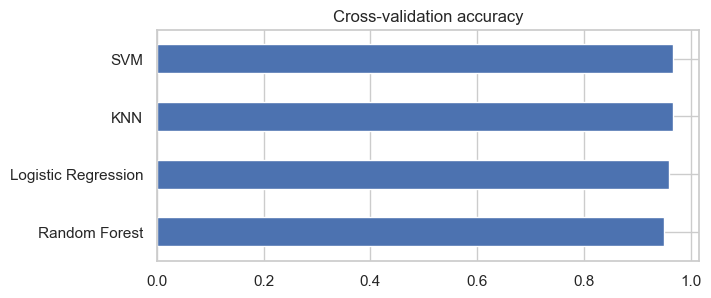

In [7]:
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=500)),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "SVM": make_pipeline(StandardScaler(), SVC()),
    "Random Forest": RandomForestClassifier(random_state=42),
}
results = {}
for name, m in models.items():
    scores = cross_val_score(m, X_train, y_train, cv=5)
    results[name] = scores.mean()
    print(f"{name:20s} CV accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

pd.Series(results).sort_values().plot(kind="barh", figsize=(7, 3), title="Cross-validation accuracy")
plt.show()

## 5. Tune the best model

In [8]:
svm = make_pipeline(StandardScaler(), SVC())
grid = GridSearchCV(svm, {"svc__C": [0.1, 1, 10, 100], "svc__kernel": ["linear", "rbf"], "svc__gamma": ["scale", 0.1, 0.01]}, cv=5)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))
best = grid.best_estimator_

Best params: {'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Best CV accuracy: 0.975


## 6. Final evaluation on the test set

Test accuracy: 0.9333

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



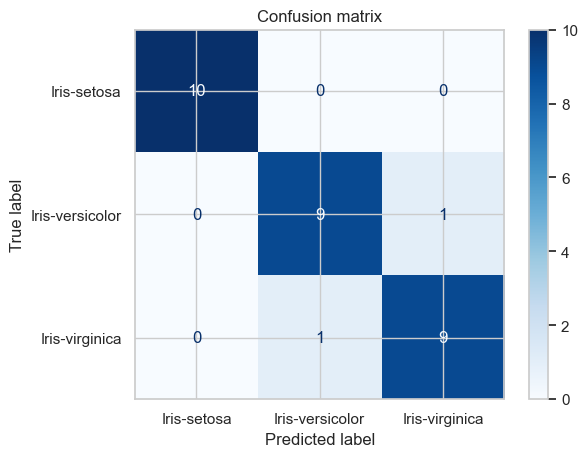

In [9]:
pred = best.predict(X_test)
print("Test accuracy:", round(accuracy_score(y_test, pred), 4))
print()
print(classification_report(y_test, pred))

ConfusionMatrixDisplay(confusion_matrix(y_test, pred, labels=best.classes_), display_labels=best.classes_).plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()

## 7. Feature importance (Random Forest)

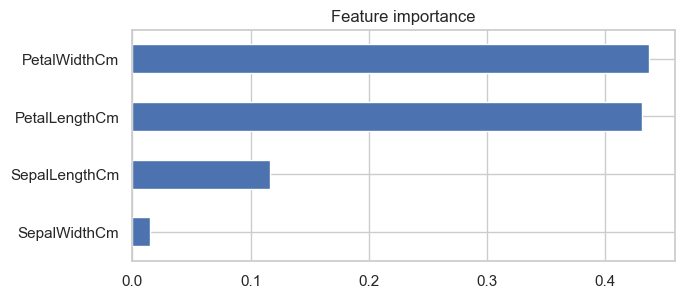

In [10]:
rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
pd.Series(rf.feature_importances_, index=features).sort_values().plot(kind="barh", figsize=(7, 3), title="Feature importance")
plt.show()

## 8. Predict a new flower

In [11]:
sample = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=features)
print("Prediction:", best.predict(sample)[0])

Prediction: Iris-setosa


## Conclusions
- The classes are almost perfectly separable; **petal length and petal width** are the most informative features.
- *Iris-setosa* is perfectly separable from the other two; the few errors occur between *versicolor* and *virginica*.
- A tuned SVM (and several other simple models) reaches ~95-100% test accuracy on this dataset.
- Because the dataset is small (150 rows), results can vary slightly with the random split; cross-validation gives a more stable estimate.